<a href="https://colab.research.google.com/github/SinhaPushkar047/ML_Learning_Projects/blob/main/04-PCA-ON-MNIST/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [267]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [268]:
pd.set_option('display.max_columns',None)

In [269]:
x_train=pd.read_csv('https://media.githubusercontent.com/media/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/04-PCA-ON-MNIST/mnist_train.csv').drop(columns='label')

In [270]:
y_train=pd.read_csv('https://media.githubusercontent.com/media/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/04-PCA-ON-MNIST/mnist_train.csv')['label']

In [271]:
x_test=pd.read_csv('https://raw.githubusercontent.com/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/04-PCA-ON-MNIST/mnist_test.csv').drop(columns='label')

In [272]:
y_test=pd.read_csv('https://raw.githubusercontent.com/SinhaPushkar047/ML_Learning_Projects/refs/heads/main/04-PCA-ON-MNIST/mnist_test.csv')['label']

In [273]:
image=x_train.iloc[5].values.reshape(28,28)

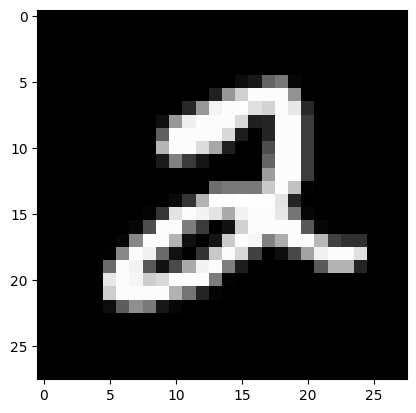

In [274]:
plt.imshow(image,cmap='gray')
plt.show()

# **Standard Scaler + PCA + Logistic Regression**

In [275]:
ss=StandardScaler()
x_train_ss=ss.fit_transform(x_train)
x_test_ss=ss.transform(x_test)

In [276]:
pca=PCA(n_components=100)

In [277]:
x_train_pca=pca.fit_transform(x_train_ss)
x_test_pca=pca.transform(x_test_ss)

In [278]:
print("x_train: ",x_train.shape)
print("x_train_pca",x_train_pca.shape)

x_train:  (60000, 784)
x_train_pca (60000, 100)


In [279]:
print("Explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: 0.7059455086308912


In [280]:
lr=LogisticRegression(max_iter=10000)

In [281]:
lr.fit(x_train_pca,y_train)

LogisticRegression(max_iter=10000)

In [282]:
x_train_pca.shape

(60000, 100)

In [283]:
y_train.shape

(60000,)

In [284]:
y_pred=lr.predict(x_test_pca)

In [285]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.90      0.90      0.90      1010
           4       0.92      0.94      0.93       982
           5       0.88      0.86      0.87       892
           6       0.94      0.95      0.94       958
           7       0.93      0.91      0.92      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.90      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



# **MinMax Scaler + PCA + Logistic Regression**

In [286]:
mms=MinMaxScaler()
x_train_scale=mms.fit_transform(x_train)
x_test_scale=mms.transform(x_test)

In [287]:
x_train_ss_pca=pca.fit_transform(x_train_scale)
x_test_ss_pca=pca.transform(x_test_scale)

In [288]:
x_train_ss_pca.shape

(60000, 100)

In [289]:
y_train.shape

(60000,)

In [290]:
lr.fit(x_train_ss_pca,y_train)

LogisticRegression(max_iter=10000)

In [291]:
y_predict=lr.predict(x_test_ss_pca)

In [292]:
print("\nClassification Report:\n", classification_report(y_test, y_predict))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.92      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.92      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



# **KNN+Standard Scaler**

In [293]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_pca, y_train)
y_pred_knn = knn.predict(x_test_pca)

In [294]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.95      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.95      0.94      0.94       892
           6       0.96      0.97      0.97       958
           7       0.95      0.94      0.95      1028
           8       0.95      0.93      0.94       974
           9       0.94      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



# **KNN+MinMaxScaler**

In [295]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_ss_pca, y_train)
y_predict_knn = knn.predict(x_test_ss_pca)

In [296]:
print("\nClassification Report:\n", classification_report(y_test, y_predict_knn))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

